In [9]:
import os
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, roc_auc_score
)
from sklearn.preprocessing import label_binarize
import seaborn as sns

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print(f'Device  : {DEVICE}')
print(f'PyTorch : {torch.__version__}')
if DEVICE.type == 'cuda':
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Device  : cuda
PyTorch : 2.5.1+cu121
GPU     : NVIDIA GeForce RTX 3050 Laptop GPU
VRAM    : 4.3 GB


In [10]:
# ── Paths ──────────────────────────────────────────────────────────────────
TRAIN_DIR = r'C:\Project\ML4SCI\Neuro\LensNet\data\train'
VAL_DIR   = r'C:\Project\ML4SCI\Neuro\LensNet\data\val'

CLASS_FOLDERS = {'no': 0, 'vort': 1, 'sphere': 2}
CLASS_NAMES   = ['no', 'vort', 'sphere']
N_CLASSES     = 3

# ── Split ──────────────────────────────────────────────────────────────────
TRAIN_FRAC = 0.90
TEST_FRAC  = 0.10

# ── FNO Hyperparameters ────────────────────────────────────────────────────
# modes1/modes2 : how many Fourier modes to retain per spatial dim
#   - Higher = captures finer frequency detail but more parameters
#   - 24 retains ~16% of freqs for 150x150 images (good for lensing)
MODES1  = 24
MODES2  = 24
WIDTH   = 32    # channel width inside FNO (hidden size)
N_FNO_BLOCKS = 4  # number of FNO blocks stacked

# ── Training ───────────────────────────────────────────────────────────────
BATCH_SIZE   = 64
EPOCHS       = 40
LR           = 3e-4
WEIGHT_DECAY = 1e-4
DROPOUT      = 0.3

print('FNO Configuration')
print(f'  Fourier modes  : {MODES1} x {MODES2}')
print(f'  Channel width  : {WIDTH}')
print(f'  FNO blocks     : {N_FNO_BLOCKS}')
print(f'  Batch size     : {BATCH_SIZE}')
print(f'  Max epochs     : {EPOCHS}')
print(f'  Learning rate  : {LR}')
print(f'  Train/Test     : {int(TRAIN_FRAC*100)}% / {int(TEST_FRAC*100)}%')

FNO Configuration
  Fourier modes  : 24 x 24
  Channel width  : 32
  FNO blocks     : 4
  Batch size     : 64
  Max epochs     : 40
  Learning rate  : 0.0003
  Train/Test     : 90% / 10%


In [11]:
class LensDataset(Dataset):
    """
    Loads .npy lens images from class subfolders.
    Handles shapes (1,150,150), (150,150), or (150,150,1).
    """
    def __init__(self, root_dir, class_folders, augment=False):
        self.samples = []
        self.augment = augment
        for folder_name, label in class_folders.items():
            folder_path = os.path.join(root_dir, folder_name)
            if not os.path.isdir(folder_path):
                raise FileNotFoundError(f'Folder not found: {folder_path}')
            files = sorted(f for f in os.listdir(folder_path) if f.endswith('.npy'))
            if not files:
                print(f'  WARNING: no .npy files in {folder_path}')
            for fname in files:
                self.samples.append((os.path.join(folder_path, fname), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        arr = np.load(path).astype(np.float32)
        if arr.ndim == 2:
            arr = arr[np.newaxis]
        elif arr.ndim == 3 and arr.shape[0] != 1:
            arr = arr.transpose(2, 0, 1)
        x = torch.from_numpy(arr)
        mn, mx = x.min(), x.max()
        if mx > mn:
            x = (x - mn) / (mx - mn)
        x = x * 2.0 - 1.0
        if self.augment:
            if torch.rand(1).item() > 0.5:
                x = torch.flip(x, dims=[2])
            if torch.rand(1).item() > 0.5:
                x = torch.flip(x, dims=[1])
            k = torch.randint(0, 4, (1,)).item()
            x = torch.rot90(x, k, dims=[1, 2])
        return x, label

print('LensDataset defined.')

LensDataset defined.


In [12]:
full_train_ds = LensDataset(TRAIN_DIR, CLASS_FOLDERS, augment=False)
val_ds        = LensDataset(VAL_DIR,   CLASS_FOLDERS, augment=False)

N       = len(full_train_ds)
n_train = int(N * TRAIN_FRAC)
n_test  = N - n_train

generator = torch.Generator().manual_seed(SEED)
train_subset, test_subset = random_split(
    full_train_ds, [n_train, n_test], generator=generator
)

class AugSubset(Dataset):
    """Applies augmentation on top of a Subset."""
    def __init__(self, subset):
        self.subset = subset
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        x, label = self.subset[idx]
        if torch.rand(1).item() > 0.5:
            x = torch.flip(x, dims=[2])
        if torch.rand(1).item() > 0.5:
            x = torch.flip(x, dims=[1])
        k = torch.randint(0, 4, (1,)).item()
        x = torch.rot90(x, k, dims=[1, 2])
        return x, label

train_ds = AugSubset(train_subset)

kw = dict(num_workers=0, pin_memory=(DEVICE.type == 'cuda'))
train_loader = DataLoader(train_ds,    batch_size=BATCH_SIZE, shuffle=True,  **kw)
test_loader  = DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=False, **kw)
val_loader   = DataLoader(val_ds,      batch_size=BATCH_SIZE, shuffle=False, **kw)

print(f'Total train-folder samples : {N:,}')
print(f'  Training (90%)           : {n_train:,}')
print(f'  Test     (10%)           : {n_test:,}')
print(f'  Validation (val/ folder) : {len(val_ds):,}')
print(f'  Train batches / epoch    : {len(train_loader)}')

Total train-folder samples : 30,000
  Training (90%)           : 27,000
  Test     (10%)           : 3,000
  Validation (val/ folder) : 7,500
  Train batches / epoch    : 422


In [13]:
class SpectralConv2d(nn.Module):
    
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super().__init__()
        self.in_channels  = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2
        scale = 1.0 / (in_channels * out_channels)
        self.weights1 = nn.Parameter(
            scale * torch.rand(in_channels, out_channels, modes1, modes2,
                               dtype=torch.cfloat)
        )
        self.weights2 = nn.Parameter(
            scale * torch.rand(in_channels, out_channels, modes1, modes2,
                               dtype=torch.cfloat)
        )

    @staticmethod
    def compl_mul2d(x, w):
        # (B, in_ch, m1, m2) x (in_ch, out_ch, m1, m2) -> (B, out_ch, m1, m2)
        return torch.einsum('bixy,ioxy->boxy', x, w)

    def forward(self, x):
        B, C, H, W = x.shape
        # Step 1: FFT
        x_ft = torch.fft.rfft2(x)                          # (B, C, H, W//2+1)
        # Step 2: spectral multiply
        out_ft = torch.zeros(B, self.out_channels, H, W // 2 + 1,
                             dtype=torch.cfloat, device=x.device)
        out_ft[:, :, :self.modes1, :self.modes2] = self.compl_mul2d(
            x_ft[:, :, :self.modes1, :self.modes2], self.weights1
        )
        out_ft[:, :, -self.modes1:, :self.modes2] = self.compl_mul2d(
            x_ft[:, :, -self.modes1:, :self.modes2], self.weights2
        )
        # Step 3: inverse FFT
        return torch.fft.irfft2(out_ft, s=(H, W))           # (B, out_ch, H, W)


class FNOBlock(nn.Module):

    def __init__(self, width, modes1, modes2):
        super().__init__()
        self.spectral = SpectralConv2d(width, width, modes1, modes2)
        self.residual = nn.Conv2d(width, width, kernel_size=1)   # pointwise
        self.bn       = nn.BatchNorm2d(width)

    def forward(self, x):
        return F.gelu(self.bn(self.spectral(x) + self.residual(x)))


class FNO2d(nn.Module):
    def __init__(self, modes1, modes2, width, n_blocks, num_classes, dropout):
        super().__init__()
        self.lift   = nn.Conv2d(1, width, kernel_size=1)
        self.blocks = nn.ModuleList([
            FNOBlock(width, modes1, modes2) for _ in range(n_blocks)
        ])
        self.project = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),          # (B, width, 1, 1)
            nn.Flatten(),                     # (B, width)
            nn.Linear(width, width * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(width * 4, width * 2),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(width * 2, num_classes),
        )

    def forward(self, x):
        x = self.lift(x)
        for block in self.blocks:
            x = block(x)
        return self.project(x)


model = FNO2d(
    modes1=MODES1, modes2=MODES2,
    width=WIDTH,   n_blocks=N_FNO_BLOCKS,
    num_classes=N_CLASSES, dropout=DROPOUT
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model      : FNO2d')
print(f'Parameters : {total_params:,}')
print(f'Modes      : {MODES1} x {MODES2}')
print(f'Width      : {WIDTH}')
print(f'Blocks     : {N_FNO_BLOCKS}')
print()
print(model)

Model      : FNO2d
Parameters : 4,735,811
Modes      : 24 x 24
Width      : 32
Blocks     : 4

FNO2d(
  (lift): Conv2d(1, 32, kernel_size=(1, 1), stride=(1, 1))
  (blocks): ModuleList(
    (0-3): 4 x FNOBlock(
      (spectral): SpectralConv2d()
      (residual): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (project): Sequential(
    (0): AdaptiveAvgPool2d(output_size=1)
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=32, out_features=128, bias=True)
    (3): GELU(approximate='none')
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=128, out_features=64, bias=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.15, inplace=False)
    (8): Linear(in_features=64, out_features=3, bias=True)
  )
)


In [14]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

optimiser = torch.optim.AdamW(
    model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY
)

# 3-epoch warm-up then cosine decay (same schedule as CNN for fair comparison)
def lr_lambda(epoch):
    warmup = 3
    if epoch < warmup:
        return (epoch + 1) / warmup
    progress = (epoch - warmup) / max(1, EPOCHS - warmup)
    return 0.5 * (1.0 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimiser, lr_lambda)

print('Loss      : CrossEntropyLoss (label_smoothing=0.05)')
print(f'Optimiser : AdamW  lr={LR}  weight_decay={WEIGHT_DECAY}')
print(f'Scheduler : 3-epoch warm-up + cosine decay over {EPOCHS} epochs')

Loss      : CrossEntropyLoss (label_smoothing=0.05)
Optimiser : AdamW  lr=0.0003  weight_decay=0.0001
Scheduler : 3-epoch warm-up + cosine decay over 40 epochs


In [16]:
def run_epoch(model, loader, optimiser, criterion, device, train=True):
    model.train() if train else model.eval()
    total_loss = correct = total = 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = (y.to(device) if isinstance(y, torch.Tensor)
                 else torch.tensor(y, dtype=torch.long, device=device))
            if train:
                optimiser.zero_grad()
            logits = model(x)
            loss   = criterion(logits, y)
            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimiser.step()
            total_loss += loss.item() * len(y)
            correct    += (logits.argmax(1) == y).sum().item()
            total      += len(y)
    return total_loss / total, correct / total


history = {
    'epoch': [], 'tr_loss': [], 'tr_acc': [],
    'val_loss': [], 'val_acc': [], 'lr': []
}

best_val_acc = 0.0
best_state   = None
no_improve   = 0
CKPT_PATH    = 'fno_lens_best.pth'

header = (f"{'Epoch':>6}  {'LR':>9}  "
          f"{'Tr Loss':>8}  {'Tr Acc':>7}  "
          f"{'Va Loss':>8}  {'Va Acc':>7}  {'':>8}  {'Time':>5}")
print(header)
print('-' * len(header))

t_start = time.time()

for epoch in range(1, EPOCHS + 1):
    ep_t0 = time.time()

    tr_loss, tr_acc   = run_epoch(model, train_loader, optimiser,
                                   criterion, DEVICE, train=True)
    val_loss, val_acc = run_epoch(model, val_loader,   optimiser,
                                   criterion, DEVICE, train=False)
    current_lr = optimiser.param_groups[0]['lr']
    scheduler.step()

    history['epoch'].append(epoch)
    history['tr_loss'].append(tr_loss)
    history['tr_acc'].append(tr_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)

    marker = ''
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        torch.save(best_state, CKPT_PATH)
        no_improve   = 0
        marker       = '<- best'
    else:
        no_improve  += 1

    ep_time = time.time() - ep_t0
    print(f"{epoch:>6}  {current_lr:>9.2e}  "
          f"{tr_loss:>8.4f}  {tr_acc:>7.4f}  "
          f"{val_loss:>8.4f}  {val_acc:>7.4f}  "
          f"{marker:<8}  [{ep_time:.0f}s]")

total_time = time.time() - t_start
print(f'\nDone  |  Best val acc : {best_val_acc:.4f}  |  Total : {total_time/60:.1f} min')
print(f'Checkpoint : {CKPT_PATH}')

 Epoch         LR   Tr Loss   Tr Acc   Va Loss   Va Acc             Time
------------------------------------------------------------------------
     1   2.00e-04    1.0988   0.3323    1.0983   0.3468  <- best   [276s]
     2   3.00e-04    1.0981   0.3466    1.0947   0.3684  <- best   [283s]
     3   3.00e-04    1.0709   0.4071    1.0349   0.4496  <- best   [290s]
     4   2.99e-04    1.0164   0.4703    0.9978   0.4843  <- best   [267s]
     5   2.98e-04    0.9853   0.4984    0.9790   0.5051  <- best   [458s]
     6   2.95e-04    0.9643   0.5167    0.9656   0.5080  <- best   [417s]
     7   2.91e-04    0.9488   0.5287    0.9451   0.5332  <- best   [408s]
     8   2.87e-04    0.9348   0.5356    0.9676   0.4976            [408s]
     9   2.81e-04    0.9235   0.5453    0.9329   0.5440  <- best   [423s]
    10   2.74e-04    0.9139   0.5536    0.9205   0.5515  <- best   [413s]
    11   2.67e-04    0.9049   0.5600    0.9121   0.5552  <- best   [415s]
    12   2.58e-04    0.8942   0.5647    

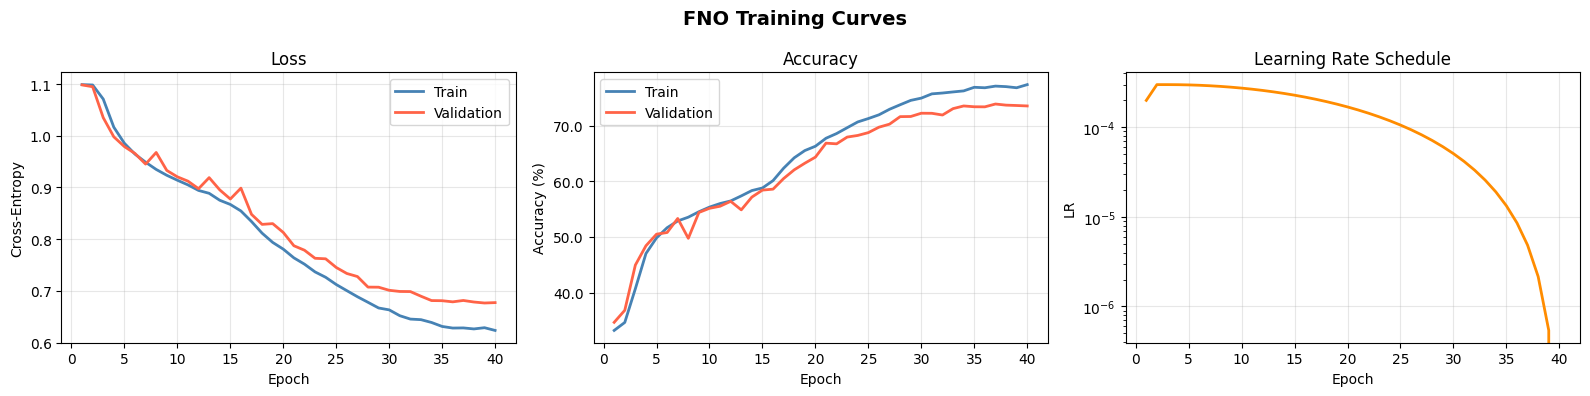

Saved: fno_training_curves.png


In [17]:
epochs_x = history['epoch']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('FNO Training Curves', fontsize=14, fontweight='bold')

# Loss
ax = axes[0]
ax.plot(epochs_x, history['tr_loss'],  label='Train',      color='steelblue', lw=2)
ax.plot(epochs_x, history['val_loss'], label='Validation', color='tomato',    lw=2)
ax.set_title('Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-Entropy')
ax.legend()
ax.grid(alpha=0.3)

# Accuracy
ax = axes[1]
ax.plot(epochs_x, [v*100 for v in history['tr_acc']],  label='Train',      color='steelblue', lw=2)
ax.plot(epochs_x, [v*100 for v in history['val_acc']], label='Validation', color='tomato',    lw=2)
ax.set_title('Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
ax.legend()
ax.grid(alpha=0.3)

# LR
ax = axes[2]
ax.plot(epochs_x, history['lr'], color='darkorange', lw=2)
ax.set_title('Learning Rate Schedule')
ax.set_xlabel('Epoch')
ax.set_ylabel('LR')
ax.set_yscale('log')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fno_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fno_training_curves.png')

In [18]:
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        y = y if isinstance(y, torch.Tensor) else torch.tensor(y, dtype=torch.long)
        logits = model(x)
        probs  = F.softmax(logits, dim=1).cpu().numpy()
        preds  = logits.argmax(1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(y.numpy())

all_probs  = np.array(all_probs)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = (all_preds == all_labels).mean()

print(f'Test Accuracy (10% held-out): {test_acc:.4f}  ({test_acc*100:.2f}%)')
print()
print(classification_report(all_labels, all_preds,
                             target_names=CLASS_NAMES, digits=4))

C:\Users\Sumit Sharma\AppData\Local\Temp\ipykernel_33560\356768550.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(CKPT_PATH, map_locati

Test Accuracy (10% held-out): 0.7363  (73.63%)

              precision    recall  f1-score   support

          no     0.7074    0.8959    0.7906      1009
        vort     0.7563    0.6771    0.7145      1059
      sphere     0.7597    0.6309    0.6893       932

    accuracy                         0.7363      3000
   macro avg     0.7411    0.7346    0.7315      3000
weighted avg     0.7409    0.7363    0.7323      3000



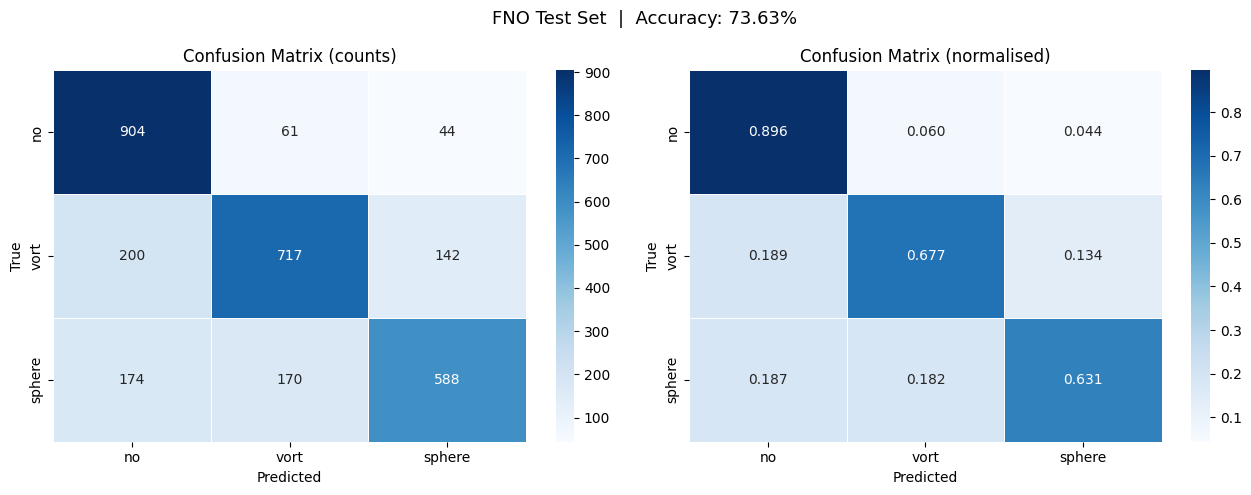

Saved: fno_confusion_matrix.png


In [19]:
cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, data, fmt, title in [
    (axes[0], cm,      'd',    'Confusion Matrix (counts)'),
    (axes[1], cm_norm, '.3f',  'Confusion Matrix (normalised)'),
]:
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, linewidths=0.5)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.suptitle(f'FNO Test Set  |  Accuracy: {test_acc*100:.2f}%', fontsize=13)
plt.tight_layout()
plt.savefig('fno_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fno_confusion_matrix.png')

In [20]:
labels_bin = label_binarize(all_labels, classes=list(range(N_CLASSES)))

CLASS_COLORS = ['#2196F3', '#FF5722', '#4CAF50']

fpr, tpr, roc_auc = {}, {}, {}

# Per-class OvR
for i in range(N_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(labels_bin[:, i], all_probs[:, i])
    roc_auc[i]        = auc(fpr[i], tpr[i])

# Micro-average
fpr['micro'], tpr['micro'], _ = roc_curve(labels_bin.ravel(), all_probs.ravel())
roc_auc['micro'] = auc(fpr['micro'], tpr['micro'])

# Macro-average
all_fpr  = np.unique(np.concatenate([fpr[i] for i in range(N_CLASSES)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(N_CLASSES):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr       /= N_CLASSES
fpr['macro']    = all_fpr
tpr['macro']    = mean_tpr
roc_auc['macro'] = auc(fpr['macro'], tpr['macro'])

# Print AUC table
print('AUC Scores (FNO — Area Under ROC Curve)')
print('=' * 42)
for i, name in enumerate(CLASS_NAMES):
    print(f'  {name:<10} (OvR) : {roc_auc[i]:.4f}')
print('-' * 42)
print(f'  {"Micro-avg":<18} : {roc_auc["micro"]:.4f}')
print(f'  {"Macro-avg":<18} : {roc_auc["macro"]:.4f}')

auc_ovr  = roc_auc_score(all_labels, all_probs, multi_class='ovr',  average='macro')
auc_ovo  = roc_auc_score(all_labels, all_probs, multi_class='ovo',  average='macro')
auc_wt   = roc_auc_score(all_labels, all_probs, multi_class='ovr',  average='weighted')
print('-' * 42)
print(f'  {"OvR macro (sklearn)":<18} : {auc_ovr:.4f}')
print(f'  {"OvO macro (sklearn)":<18} : {auc_ovo:.4f}')
print(f'  {"OvR weighted":<18} : {auc_wt:.4f}')
print('=' * 42)

AUC Scores (FNO — Area Under ROC Curve)
  no         (OvR) : 0.9280
  vort       (OvR) : 0.8799
  sphere     (OvR) : 0.8626
------------------------------------------
  Micro-avg          : 0.8954
  Macro-avg          : 0.8904
------------------------------------------
  OvR macro (sklearn) : 0.8902
  OvO macro (sklearn) : 0.8898
  OvR weighted       : 0.8907


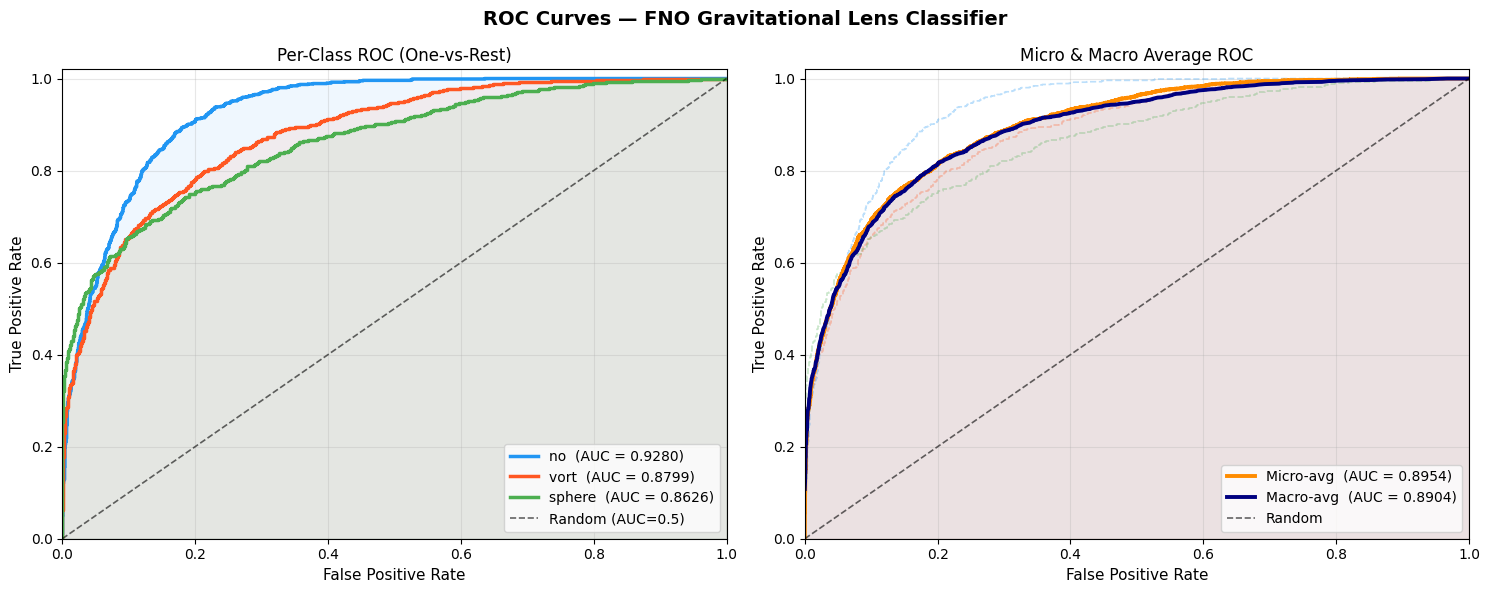

Saved: fno_roc_curves.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('ROC Curves — FNO Gravitational Lens Classifier',
             fontsize=14, fontweight='bold')

# Left: per-class OvR
ax = axes[0]
for i, name in enumerate(CLASS_NAMES):
    ax.plot(fpr[i], tpr[i], color=CLASS_COLORS[i], lw=2.5,
            label=f'{name}  (AUC = {roc_auc[i]:.4f})')
    ax.fill_between(fpr[i], tpr[i], alpha=0.07, color=CLASS_COLORS[i])
ax.plot([0,1],[0,1],'k--',lw=1.2,alpha=0.6,label='Random (AUC=0.5)')
ax.set_title('Per-Class ROC (One-vs-Rest)', fontsize=12)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.grid(alpha=0.3)

# Right: micro + macro
ax = axes[1]
for i, name in enumerate(CLASS_NAMES):
    ax.plot(fpr[i], tpr[i], color=CLASS_COLORS[i], lw=1.2, alpha=0.3, linestyle='--')
ax.plot(fpr['micro'], tpr['micro'], color='darkorange', lw=2.8,
        label=f'Micro-avg  (AUC = {roc_auc["micro"]:.4f})')
ax.plot(fpr['macro'], tpr['macro'], color='navy',       lw=2.8,
        label=f'Macro-avg  (AUC = {roc_auc["macro"]:.4f})')
ax.fill_between(fpr['micro'], tpr['micro'], alpha=0.08, color='darkorange')
ax.fill_between(fpr['macro'], tpr['macro'], alpha=0.08, color='navy')
ax.plot([0,1],[0,1],'k--',lw=1.2,alpha=0.6,label='Random')
ax.set_title('Micro & Macro Average ROC', fontsize=12)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fno_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fno_roc_curves.png')

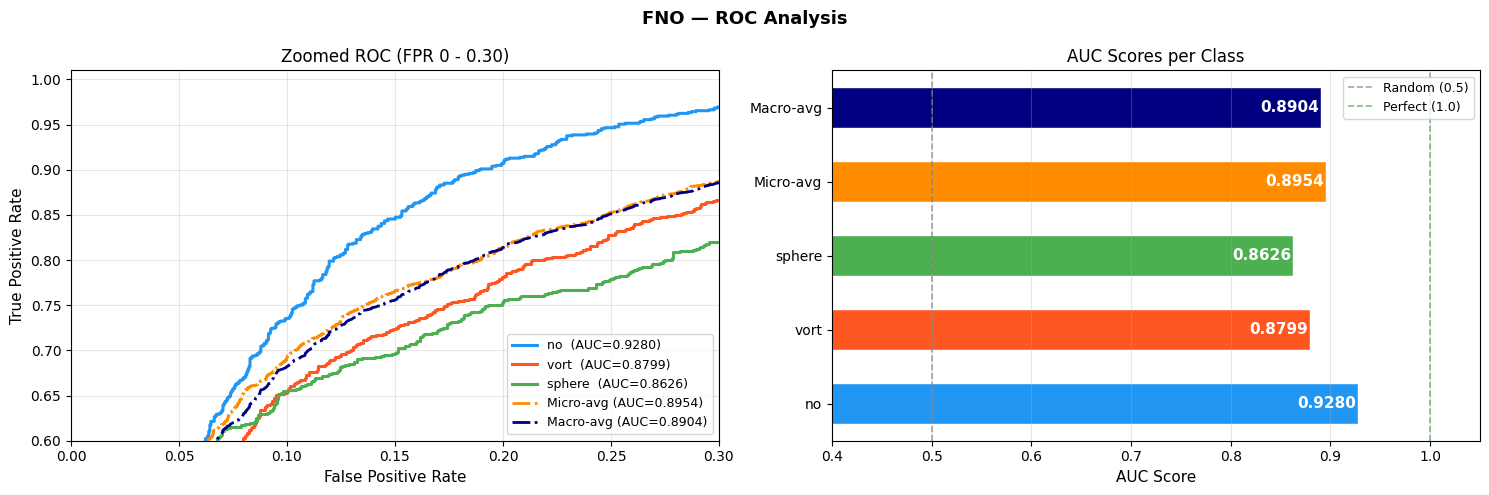

Saved: fno_roc_zoomed_auc_bar.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: Zoomed 0-0.3 FPR
ax = axes[0]
for i, name in enumerate(CLASS_NAMES):
    ax.plot(fpr[i], tpr[i], color=CLASS_COLORS[i], lw=2.2,
            label=f'{name}  (AUC={roc_auc[i]:.4f})')
ax.plot(fpr['micro'], tpr['micro'], color='darkorange', lw=2, linestyle='-.',
        label=f'Micro-avg (AUC={roc_auc["micro"]:.4f})')
ax.plot(fpr['macro'], tpr['macro'], color='navy',       lw=2, linestyle='-.',
        label=f'Macro-avg (AUC={roc_auc["macro"]:.4f})')
ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
ax.set_xlim([0.0, 0.30]); ax.set_ylim([0.60, 1.01])
ax.set_title('Zoomed ROC (FPR 0 - 0.30)', fontsize=12)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

# Right: AUC bar
ax = axes[1]
bar_labels = CLASS_NAMES + ['Micro-avg', 'Macro-avg']
bar_values = [roc_auc[i] for i in range(N_CLASSES)] + \
             [roc_auc['micro'], roc_auc['macro']]
bar_colors = CLASS_COLORS + ['darkorange', 'navy']
bars = ax.barh(bar_labels, bar_values, color=bar_colors,
               edgecolor='white', height=0.55)
for bar, val in zip(bars, bar_values):
    ax.text(bar.get_width() - 0.002,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', ha='right',
            fontsize=11, fontweight='bold', color='white')
ax.axvline(0.5, color='gray',  linestyle='--', lw=1.2, alpha=0.7, label='Random (0.5)')
ax.axvline(1.0, color='green', linestyle='--', lw=1.2, alpha=0.5, label='Perfect (1.0)')
ax.set_xlim([0.4, 1.05])
ax.set_xlabel('AUC Score', fontsize=11)
ax.set_title('AUC Scores per Class', fontsize=12)
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)

plt.suptitle('FNO — ROC Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fno_roc_zoomed_auc_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fno_roc_zoomed_auc_bar.png')

In [27]:
print(f"{'Class':<10}  {'Correct':>8}  {'Total':>8}  {'Accuracy':>10}")
print('-' * 42)
for cls_idx, name in enumerate(CLASS_NAMES):
    mask    = all_labels == cls_idx
    correct = (all_preds[mask] == cls_idx).sum()
    total   = mask.sum()
    acc     = correct / total if total > 0 else 0.0
    print(f'{name:<10}  {correct:>8}  {total:>8}  {acc:>10.4f}')
print('-' * 42)
print(f"{'Overall':<10}  {(all_preds==all_labels).sum():>8}  "
      f"{len(all_labels):>8}  {test_acc:>10.4f}")

best_ep  = history['val_acc'].index(max(history['val_acc'])) + 1
best_val = max(history['val_acc'])

print()
print('=' * 52)
print('  FNO LENS CLASSIFIER — FINAL RESULTS')
print('=' * 52)
print(f'  Training samples  : {n_train:,}  (90%)')
print(f'  Test samples      : {n_test:,}  (10%)')
print(f'  Validation samples: {len(val_ds):,}')
print(f'  Model parameters  : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')
print(f'  Fourier modes     : {MODES1} x {MODES2}')
print(f'  FNO blocks        : {N_FNO_BLOCKS}')
print(f'  Epochs trained    : {len(history["epoch"])}')
print(f'  Best epoch        : {best_ep}  (val acc = {best_val:.4f})')
print(f'  Test accuracy     : {test_acc:.4f}  ({test_acc*100:.2f}%)')
print(f'  AUC macro-avg     : {roc_auc["macro"]:.4f}')
print(f'  AUC micro-avg     : {roc_auc["micro"]:.4f}')
print('=' * 52)
print(f'  Checkpoint        : {CKPT_PATH}')
print('=' * 52)

Class        Correct     Total    Accuracy
------------------------------------------
no               904      1009      0.8959
vort             717      1059      0.6771
sphere           588       932      0.6309
------------------------------------------
Overall         2209      3000      0.7363

  FNO LENS CLASSIFIER — FINAL RESULTS
  Training samples  : 27,000  (90%)
  Test samples      : 3,000  (10%)
  Validation samples: 7,500
  Model parameters  : 4,735,811
  Fourier modes     : 24 x 24
  FNO blocks        : 4
  Epochs trained    : 40
  Best epoch        : 37  (val acc = 0.7387)
  Test accuracy     : 0.7363  (73.63%)
  AUC macro-avg     : 0.8904
  AUC micro-avg     : 0.8954
  Checkpoint        : fno_lens_best.pth
